In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as geopd
import matplotlib.pyplot as plt
import subprocess

## Config

In [2]:
DIR = "/home/dy23a.fsu/st/datasets/raw"
DIR = os.path.join(DIR, "Chicago")
TAXI_FILE = Path(DIR) / "chi_taxi_2025_15min.csv"
TNP_DIR = Path(DIR) / "TNP"
SCOOTER_FILE = Path(DIR) / "chi_scooter_2025_60min.csv"
BIKE_DIR = Path(DIR) / "bike"

# OD trips are binned by a single timestamp. As in the flow notebook, FLOW_MODE
# selects which leg's time stamps the trip:
#   departure -> pickup/start time   (when the trip leaves the origin)
#   arrival   -> dropoff/end time    (when the trip reaches the destination)
# The origin (O) and destination (D) regions are always the pickup and dropoff
# community areas respectively, regardless of FLOW_MODE.
FLOW_MODE = "departure"  # departure -> pickup/start ; arrival -> dropoff/end
assert FLOW_MODE in {"arrival", "departure"}

AREAS_PATH = "./Chicago Community Areas.geojson"

OUT_DIR = Path(DIR)

# Sub-region filter analogous to NYC's borough filter.
# Set to a list of community area numbers (e.g. central area: [8, 28, 32, 33, 76])
# to keep only those areas; leave as None / "all" to keep every community area.
TARGET_AREAS = None
TARGET_TAG = "central"  # filename tag used when TARGET_AREAS is set

In [3]:
YEAR = 2025
FREQ = "15min"
FREQ_SCOOTER = "60min"
TIME_START = pd.Timestamp(f"{YEAR}-01-01 00:00:00")
TIME_END = pd.Timestamp(f"{YEAR + 1}-01-01 00:00:00")

def make_grid(freq):
    steps = pd.date_range(TIME_START, TIME_END, freq=freq, inclusive="left")
    return steps, len(steps)

STEPS, T = make_grid(FREQ)
STEPS_SCOOTER, T_SCOOTER = make_grid(FREQ_SCOOTER)
FREQ_TAG = FREQ
FREQ_TAG_SCOOTER = FREQ_SCOOTER
print(f"YEAR={YEAR}, FREQ={FREQ} (T={T}), FREQ_SCOOTER={FREQ_SCOOTER} (T={T_SCOOTER}), FLOW_MODE={FLOW_MODE}")

YEAR=2025, FREQ=15min (T=35040), FREQ_SCOOTER=60min (T=8760), FLOW_MODE=departure


## Shapefile and helpers

Region order follows the shapefile (sorted by community area number). Unlike the
flow notebook -- which builds `(N, T)` per region -- an OD matrix is `N x N` per
step. Chicago has only `N=77` community areas, so the full `(N, N, T)` tensor is
small (~1.7 GB per 15-min mobility); we therefore build the **full** OD tensor
and apply the optional `TARGET_AREAS` filter afterwards (mirroring the flow
notebook's filter-after pattern). All output `(N, N, M, T)` arrays use the
shapefile order (origin axis first, destination axis second).

In [4]:
areas = geopd.read_file(AREAS_PATH).to_crs("EPSG:4326")
areas["area_number"] = pd.to_numeric(areas["area_numbe"], errors="coerce").astype("Int64")
areas = areas.dropna(subset=["area_number"]).sort_values("area_number").reset_index(drop=True)
areas["region_idx"] = np.arange(len(areas), dtype=np.int32)
areas_for_join = areas[["region_idx", "geometry"]]
N = len(areas)
bounds = areas.total_bounds
area_to_region = {int(a): idx for idx, a in enumerate(areas["area_number"].astype(int).tolist())}
print(f"N={N} community areas, bbox={bounds}")

N=77 community areas, bbox=[-87.94011408  41.64454312 -87.5241371   42.02303859]


In [5]:
def make_step_idx_fn(freq, n_t):
    def fn(ts_series):
        ts = pd.to_datetime(ts_series, errors="coerce")
        step = ts.dt.floor(freq)
        delta = (step - TIME_START) / pd.Timedelta(freq)
        idx_float = delta.to_numpy(dtype=np.float64)
        valid = np.isfinite(idx_float) & (idx_float >= 0) & (idx_float < n_t)
        step_idx = np.zeros(len(idx_float), dtype=np.int64)
        step_idx[valid] = idx_float[valid].astype(np.int64)
        return step_idx, valid
    return fn

step_idx_15 = make_step_idx_fn(FREQ, T)
step_idx_60 = make_step_idx_fn(FREQ_SCOOTER, T_SCOOTER)

def map_points_to_regions(lon_arr, lat_arr, join_gdf, bounds_):
    minx, miny, maxx, maxy = bounds_
    region_idx = np.full(len(lon_arr), -1, dtype=np.int32)
    in_bbox = (
        (lon_arr >= minx)
        & (lon_arr <= maxx)
        & (lat_arr >= miny)
        & (lat_arr <= maxy)
    )
    if not np.any(in_bbox):
        return region_idx
    candidate_ids = np.where(in_bbox)[0]
    pts = geopd.GeoDataFrame(
        {"row_id": candidate_ids},
        geometry=geopd.points_from_xy(lon_arr[in_bbox], lat_arr[in_bbox]),
        crs="EPSG:4326",
    )
    joined = geopd.sjoin(pts, join_gdf, how="left", predicate="intersects")
    matched = joined.dropna(subset=["region_idx"]).drop_duplicates(subset=["row_id"], keep="first")
    region_idx[matched["row_id"].to_numpy(dtype=np.int64)] = matched["region_idx"].to_numpy(dtype=np.int32)
    return region_idx

def accumulate_od(o_region, d_region, step_idx, time_valid, od_matrix, n_t):
    """Bin trips into an (N, N, n_t) origin-destination matrix (in-place).

    o_region / d_region are shapefile region indices (0..N-1, or -1 to drop).
    A trip is kept only when both endpoints map to a valid region.
    """
    n = od_matrix.shape[0]
    valid = time_valid & (o_region >= 0) & (d_region >= 0)
    if not np.any(valid):
        return 0
    flat_idx = (
        (o_region[valid].astype(np.int64) * n + d_region[valid].astype(np.int64)) * n_t
        + step_idx[valid].astype(np.int64)
    )
    binc = np.bincount(flat_idx, minlength=n * n * n_t)
    od_matrix += binc.reshape(n, n, n_t)
    return int(valid.sum())

## Taxi OD

The Chicago taxi CSV carries `pickup_community_area` / `dropoff_community_area`,
mapped directly to `region_idx` via the shapefile order. Origin is the pickup
area, destination the dropoff area; `FLOW_MODE` only chooses which timestamp
(start vs. end) bins the trip.

In [6]:
def process_area_od_csv(path, pu_area_col, do_area_col, time_col, step_idx_fn, n_t, chunksize=500_000):
    """OD binning for CSVs that already carry pickup/dropoff community area columns."""
    od = np.zeros((N, N, n_t), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    print(f"Processing {path.name} [O={pu_area_col}, D={do_area_col}, t={time_col}]")
    reader = pd.read_csv(path, usecols=[pu_area_col, do_area_col, time_col],
                         chunksize=chunksize, low_memory=False)
    for chunk in reader:
        total_rows += len(chunk)
        chunk = chunk.dropna(subset=[pu_area_col, do_area_col, time_col])
        if chunk.empty:
            continue
        pu = pd.to_numeric(chunk[pu_area_col], errors="coerce")
        do = pd.to_numeric(chunk[do_area_col], errors="coerce")
        valid_area = pu.notna() & do.notna()
        if not valid_area.any():
            continue
        pu = pu[valid_area].astype(np.int64).reset_index(drop=True)
        do = do[valid_area].astype(np.int64).reset_index(drop=True)
        ts = chunk.loc[valid_area, time_col].reset_index(drop=True)
        o_region = pu.map(area_to_region).fillna(-1).to_numpy(dtype=np.int32)
        d_region = do.map(area_to_region).fillna(-1).to_numpy(dtype=np.int32)
        step_idx, time_valid = step_idx_fn(ts)
        kept_rows += accumulate_od(o_region, d_region, step_idx, time_valid, od, n_t)
    print(f"Rows seen: {total_rows:,}, kept in OD: {kept_rows:,}")
    return od

In [7]:
taxi_pu_col, taxi_do_col = "pickup_community_area", "dropoff_community_area"
taxi_time_col = "trip_end_timestamp" if FLOW_MODE == "arrival" else "trip_start_timestamp"

if not TAXI_FILE.exists():
    raise FileNotFoundError(f"Taxi file not found: {TAXI_FILE}")
chi_taxi_od = process_area_od_csv(TAXI_FILE, taxi_pu_col, taxi_do_col, taxi_time_col, step_idx_15, T)
taxi_out = OUT_DIR / f"chi_taxi_od_{YEAR}_{FREQ_TAG}.npy"
np.save(taxi_out, chi_taxi_od)
print(f"Saved {taxi_out} shape={chi_taxi_od.shape} (O,D,T), total={chi_taxi_od.sum():,}")

Processing chi_taxi_2025_15min.csv [O=pickup_community_area, D=dropoff_community_area, t=trip_start_timestamp]
Rows seen: 6,825,838, kept in OD: 6,174,716
Saved /home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_od_2025_15min.npy shape=(77, 77, 35040) (O,D,T), total=6,174,716


## TNP OD (Transportation Network Providers)

Same `pickup_community_area` / `dropoff_community_area` schema as taxi, split
across monthly files. Density is higher than taxi because TNP covers all of
Chicago.

In [8]:
tnp_pu_col, tnp_do_col = "pickup_community_area", "dropoff_community_area"
tnp_time_col = "trip_end_timestamp" if FLOW_MODE == "arrival" else "trip_start_timestamp"

tnp_files = sorted(TNP_DIR.glob(f"chi_TNP_{YEAR}_*_15min.csv"))
if not tnp_files:
    raise FileNotFoundError(f"No TNP CSV files found under {TNP_DIR}")

chi_tnp_od = np.zeros((N, N, T), dtype=np.int64)
for fp in tnp_files:
    chi_tnp_od += process_area_od_csv(fp, tnp_pu_col, tnp_do_col, tnp_time_col, step_idx_15, T)

tnp_out = OUT_DIR / f"chi_tnp_od_{YEAR}_{FREQ_TAG}.npy"
np.save(tnp_out, chi_tnp_od)
print(f"Saved {tnp_out} shape={chi_tnp_od.shape} (O,D,T), total={chi_tnp_od.sum():,}")

Processing chi_TNP_2025_01_15min.csv [O=pickup_community_area, D=dropoff_community_area, t=trip_start_timestamp]
Rows seen: 7,607,290, kept in OD: 6,223,914
Processing chi_TNP_2025_02_15min.csv [O=pickup_community_area, D=dropoff_community_area, t=trip_start_timestamp]
Rows seen: 7,288,575, kept in OD: 5,960,580
Processing chi_TNP_2025_03_15min.csv [O=pickup_community_area, D=dropoff_community_area, t=trip_start_timestamp]
Rows seen: 8,037,030, kept in OD: 6,522,972
Processing chi_TNP_2025_04_15min.csv [O=pickup_community_area, D=dropoff_community_area, t=trip_start_timestamp]
Rows seen: 7,535,395, kept in OD: 6,017,609
Processing chi_TNP_2025_05_15min.csv [O=pickup_community_area, D=dropoff_community_area, t=trip_start_timestamp]
Rows seen: 8,087,664, kept in OD: 6,528,420
Processing chi_TNP_2025_06_15min.csv [O=pickup_community_area, D=dropoff_community_area, t=trip_start_timestamp]
Rows seen: 7,690,883, kept in OD: 6,156,828
Processing chi_TNP_2025_07_15min.csv [O=pickup_community_a

## Scooter OD

Chicago publishes scooter trips on a **60-minute** grid (privacy preserving),
so this mobility lives on its own `(N, N, T_SCOOTER)` grid and is **not** stacked
into the 15-min merge below. Columns are `start_community_area_number` /
`end_community_area_number` and `start_time` / `end_time`.

In [9]:
scooter_pu_col, scooter_do_col = "start_community_area_number", "end_community_area_number"
scooter_time_col = "end_time" if FLOW_MODE == "arrival" else "start_time"

if not SCOOTER_FILE.exists():
    raise FileNotFoundError(f"Scooter file not found: {SCOOTER_FILE}")
chi_scooter_od = process_area_od_csv(SCOOTER_FILE, scooter_pu_col, scooter_do_col,
                                     scooter_time_col, step_idx_60, T_SCOOTER)
scooter_out = OUT_DIR / f"chi_scooter_od_{YEAR}_{FREQ_TAG_SCOOTER}.npy"
np.save(scooter_out, chi_scooter_od)
print(f"Saved {scooter_out} shape={chi_scooter_od.shape} (O,D,T), total={chi_scooter_od.sum():,}")

Processing chi_scooter_2025_60min.csv [O=start_community_area_number, D=end_community_area_number, t=start_time]
Rows seen: 9,452,755, kept in OD: 9,432,242
Saved /home/dy23a.fsu/st/datasets/raw/Chicago/chi_scooter_od_2025_60min.npy shape=(77, 77, 8760) (O,D,T), total=9,432,242


## Bike OD (gps -> shapefile)

Divvy CSVs only carry station lat/lon, so both the start and end points are
spatially joined to a community-area polygon. File pattern is
`{YYYYMM}-divvy-tripdata.csv`.

In [10]:
def process_bike_od_csv(files, chunksize=500_000):
    od = np.zeros((N, N, T), dtype=np.int64)
    total_rows = 0
    kept_rows = 0
    time_col = "ended_at" if FLOW_MODE == "arrival" else "started_at"
    usecols = ["start_lng", "start_lat", "end_lng", "end_lat", time_col]
    for fp in files:
        print(f"Processing {fp.name}")
        reader = pd.read_csv(fp, usecols=usecols, chunksize=chunksize, low_memory=False)
        for chunk in reader:
            total_rows += len(chunk)
            chunk = chunk.dropna(subset=usecols)
            if chunk.empty:
                continue
            o_lon = pd.to_numeric(chunk["start_lng"], errors="coerce").to_numpy(dtype=np.float64)
            o_lat = pd.to_numeric(chunk["start_lat"], errors="coerce").to_numpy(dtype=np.float64)
            d_lon = pd.to_numeric(chunk["end_lng"], errors="coerce").to_numpy(dtype=np.float64)
            d_lat = pd.to_numeric(chunk["end_lat"], errors="coerce").to_numpy(dtype=np.float64)
            valid_xy = (
                np.isfinite(o_lon) & np.isfinite(o_lat)
                & np.isfinite(d_lon) & np.isfinite(d_lat)
            )
            if not np.any(valid_xy):
                continue
            o_lon, o_lat = o_lon[valid_xy], o_lat[valid_xy]
            d_lon, d_lat = d_lon[valid_xy], d_lat[valid_xy]
            ts = chunk.loc[valid_xy, time_col].reset_index(drop=True)
            o_region = map_points_to_regions(o_lon, o_lat, areas_for_join, bounds)
            d_region = map_points_to_regions(d_lon, d_lat, areas_for_join, bounds)
            step_idx, time_valid = step_idx_15(ts)
            kept_rows += accumulate_od(o_region, d_region, step_idx, time_valid, od, T)
    print(f"Rows seen: {total_rows:,}, kept in OD: {kept_rows:,}")
    return od

bike_files = sorted(BIKE_DIR.glob(f"{YEAR}??-divvy-tripdata.csv"))
if not bike_files:
    raise FileNotFoundError(f"No Divvy bike CSV files found under {BIKE_DIR}")
chi_bike_od = process_bike_od_csv(bike_files)
bike_out = OUT_DIR / f"chi_bike_od_{YEAR}_{FREQ_TAG}.npy"
np.save(bike_out, chi_bike_od)
print(f"Saved {bike_out} shape={chi_bike_od.shape} (O,D,T), total={chi_bike_od.sum():,}")

Processing 202501-divvy-tripdata.csv
Processing 202502-divvy-tripdata.csv
Processing 202503-divvy-tripdata.csv
Processing 202504-divvy-tripdata.csv
Processing 202505-divvy-tripdata.csv
Processing 202506-divvy-tripdata.csv
Processing 202507-divvy-tripdata.csv
Processing 202508-divvy-tripdata.csv
Processing 202509-divvy-tripdata.csv
Processing 202510-divvy-tripdata.csv
Processing 202511-divvy-tripdata.csv
Processing 202512-divvy-tripdata.csv
Rows seen: 5,552,994, kept in OD: 5,403,610
Saved /home/dy23a.fsu/st/datasets/raw/Chicago/chi_bike_od_2025_15min.npy shape=(77, 77, 35040) (O,D,T), total=5,403,610


## Summary

In [11]:
def summarize_od(name, arr):
    arr = np.asarray(arr)
    total = float(arr.sum())
    nnz = int(np.count_nonzero(arr))
    density = 100.0 * nnz / arr.size if arr.size else 0.0
    pair_flow = arr.sum(axis=2)                      # (O, D) total over time
    active_pairs = int((pair_flow > 0).sum())
    active_o = int((arr.sum(axis=(1, 2)) > 0).sum())
    active_d = int((arr.sum(axis=(0, 2)) > 0).sum())
    active_steps = int((arr.sum(axis=(0, 1)) > 0).sum())
    print(f"[{name}] shape={arr.shape}, total={total:,.0f}, nnz={nnz:,} ({density:.3f}%), "
          f"active_pairs={active_pairs}/{arr.shape[0] * arr.shape[1]}, "
          f"active_O={active_o}/{arr.shape[0]}, active_D={active_d}/{arr.shape[1]}, "
          f"active_steps={active_steps}/{arr.shape[2]}")

for name, arr in [("taxi", chi_taxi_od), ("tnp", chi_tnp_od), ("bike", chi_bike_od), ("scooter", chi_scooter_od)]:
    summarize_od(name, arr)

[taxi] shape=(77, 77, 35040), total=6,174,716, nnz=2,676,732 (1.288%), active_pairs=5498/5929, active_O=77/77, active_D=77/77, active_steps=35036/35040
[tnp] shape=(77, 77, 35040), total=75,372,215, nnz=25,536,018 (12.292%), active_pairs=5924/5929, active_O=77/77, active_D=77/77, active_steps=35036/35040
[bike] shape=(77, 77, 35040), total=5,403,610, nnz=1,763,280 (0.849%), active_pairs=2913/5929, active_O=77/77, active_D=77/77, active_steps=34882/35040
[scooter] shape=(77, 77, 8760), total=9,432,242, nnz=1,859,041 (3.579%), active_pairs=3551/5929, active_O=77/77, active_D=77/77, active_steps=8692/8760


## Filter by Community Areas

If `TARGET_AREAS` is a list of community area numbers, select the matching rows
**and** columns from each `(N, N, T)` OD tensor using the shapefile index, write
`chi_<tag>_<mobility>_od_<year>_<freq>.npy`, and export the filtered region
GeoJSON in the same order. Set `TARGET_AREAS=None` to keep all 77 areas.

In [12]:
if TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all"):
    target_set = {int(a) for a in TARGET_AREAS}
    mask = areas["area_number"].astype(int).isin(target_set)
    sel_idx = np.where(mask.to_numpy())[0]
    if sel_idx.size == 0:
        raise ValueError(f"No community areas matched TARGET_AREAS={TARGET_AREAS}")
    areas_sel = areas.iloc[sel_idx].reset_index(drop=True)
    area_tag = TARGET_TAG.lower().replace(" ", "_")
    geo_path = OUT_DIR / f"{area_tag}.geojson"
    areas_sel.drop(columns=["region_idx"], errors="ignore").to_file(geo_path, driver="GeoJSON")
    print(f"TARGET_AREAS={sorted(target_set)}, kept {len(sel_idx)}/{N} areas -> {geo_path}")
    for name, arr, freq_tag in [
        ("taxi", chi_taxi_od, FREQ_TAG),
        ("tnp", chi_tnp_od, FREQ_TAG),
        ("bike", chi_bike_od, FREQ_TAG),
        ("scooter", chi_scooter_od, FREQ_TAG_SCOOTER),
    ]:
        sub = arr[np.ix_(sel_idx, sel_idx)]           # (k, k, T)
        out = OUT_DIR / f"chi_{area_tag}_{name}_od_{YEAR}_{freq_tag}.npy"
        np.save(out, sub)
        print(f"  {out} shape={sub.shape}, total={sub.sum():,}")
else:
    sel_idx = np.arange(N)
    areas_sel = areas.copy()
    area_tag = "all"
    print(f"Area filter disabled, keeping all {N} community areas")

Area filter disabled, keeping all 77 community areas


## Merge mobilities -> (N, N, M, T)

Stack the **15-min** mobilities `["taxi", "tnp", "bike"]` along a new mobility
axis to get the final `(N, N, M, T)` tensor (origin, destination, mobility,
time). Scooter is on a 60-min grid and is therefore not part of this merge.

In [13]:
MERGE_MOBILITIES = ["taxi", "tnp", "bike"]
MOBILITY_ARRS = {"taxi": chi_taxi_od, "tnp": chi_tnp_od, "bike": chi_bike_od}
missing = [m for m in MERGE_MOBILITIES if m not in MOBILITY_ARRS]
if missing:
    raise ValueError(f"Unknown mobilities in MERGE_MOBILITIES: {missing}")

# (O, D, T) per mobility -> stack on axis=2 -> (N, N, M, T)
merged = np.stack([MOBILITY_ARRS[m] for m in MERGE_MOBILITIES], axis=2)
merged_tag = "_".join(MERGE_MOBILITIES)
M_dim = len(MERGE_MOBILITIES)
merged_out = OUT_DIR / f"chi_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
np.save(merged_out, merged)
print(f"{merged_out} shape={merged.shape} (N, N, M, T) with M={M_dim} mobilities")

if TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all"):
    merged_a = merged[np.ix_(sel_idx, sel_idx)]       # (k, k, M, T)
    merged_a_out = OUT_DIR / f"chi_{area_tag}_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
    np.save(merged_a_out, merged_a)
    print(f"{merged_a_out} shape={merged_a.shape} (N, N, M, T)")

/home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_od_2025_15min.npy shape=(77, 77, 3, 35040) (N, N, M, T) with M=3 mobilities


## Visualization & Sparsity Report

For each mobility (`taxi`, `tnp`, `bike`, `scooter`):
- **OD heatmap**: log1p total origin-destination flow `(O x D)` over the year.
- **Origin/destination choropleth**: total outflow / inflow per area on the
  shapefile.
- **Temporal panels**: daily total OD flow + weekday x hour-of-day occupancy.
- **Sparsity report**: zero-rate over `(O, D, T)`, dead pairs / origins /
  destinations / steps, and per-pair / per-step quantiles.

Each mobility uses its own time grid (15-min for taxi/tnp/bike, 60-min for
scooter). The choropleths use the full shapefile; OD heatmaps use local indices.

In [14]:
MOBILITY_VIZ = [
    ("taxi", chi_taxi_od, STEPS),
    ("tnp", chi_tnp_od, STEPS),
    ("bike", chi_bike_od, STEPS),
    ("scooter", chi_scooter_od, STEPS_SCOOTER),
]

def plot_od_heat(arr, title):
    pair = np.asarray(arr).sum(axis=2)              # (O, D)
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    im = ax.imshow(np.log1p(pair), aspect="auto", cmap="magma", origin="upper")
    ax.set_title(title)
    ax.set_xlabel("Destination region (idx)")
    ax.set_ylabel("Origin region (idx)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="log1p(total flow)")
    plt.tight_layout()
    plt.show()

def plot_area_heat(area_gdf, values, title, cmap="YlOrRd", log=True):
    plot_gdf = area_gdf.copy()
    vals = np.asarray(values, dtype=np.float64)
    plot_gdf["flow"] = np.log1p(vals) if log else vals
    legend_label = "log1p(total flow)" if log else "total flow"
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    plot_gdf.plot(column="flow", cmap=cmap, linewidth=0.2, edgecolor="black",
                  legend=True, legend_kwds={"label": legend_label, "shrink": 0.6}, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def sparsity_report(name, arr, time_index):
    arr = np.asarray(arr)
    total_cells = arr.size
    nnz = int(np.count_nonzero(arr))
    zero_rate = 1.0 - nnz / total_cells if total_cells else 0.0
    total_flow = float(arr.sum())
    pair_sum = arr.sum(axis=2).reshape(-1)
    step_sum = arr.sum(axis=(0, 1))
    dead_pairs = int((pair_sum == 0).sum())
    dead_steps = int((step_sum == 0).sum())
    pair_q = np.quantile(pair_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    step_q = np.quantile(step_sum, [0.0, 0.25, 0.5, 0.75, 1.0])
    nz_pair_q = np.quantile(pair_sum[pair_sum > 0], [0.25, 0.5, 0.75]) if (pair_sum > 0).any() else np.array([0, 0, 0])
    print(f"=== Sparsity report: {name} ===")
    print(f"  shape={arr.shape}, total_flow={total_flow:,.0f}")
    print(f"  nnz cells={nnz:,}/{total_cells:,}  zero_rate={zero_rate*100:.3f}%")
    print(f"  dead pairs={dead_pairs}/{pair_sum.size}  dead steps={dead_steps}/{arr.shape[2]}")
    print(f"  pair totals  min/Q1/med/Q3/max = {pair_q[0]:,.0f} / {pair_q[1]:,.0f} / {pair_q[2]:,.0f} / {pair_q[3]:,.0f} / {pair_q[4]:,.0f}")
    print(f"  pair totals  (non-zero only) Q1/med/Q3 = {nz_pair_q[0]:,.0f} / {nz_pair_q[1]:,.0f} / {nz_pair_q[2]:,.0f}")
    print(f"  step totals  min/Q1/med/Q3/max = {step_q[0]:,.0f} / {step_q[1]:,.0f} / {step_q[2]:,.0f} / {step_q[3]:,.0f} / {step_q[4]:,.0f}")
    idx_active = np.where(step_sum > 0)[0]
    if idx_active.size:
        print(f"  first_active={pd.Timestamp(time_index[idx_active[0]])}, last_active={pd.Timestamp(time_index[idx_active[-1]])}")

def plot_temporal_panels(name, arr, time_index):
    arr = np.asarray(arr)
    ts = pd.to_datetime(time_index)
    series = pd.Series(arr.sum(axis=(0, 1)), index=ts)
    daily = series.resample("D").sum()
    hod = pd.DataFrame({"flow": series.values}, index=ts)
    hod["dow"] = hod.index.dayofweek
    hod["hour"] = hod.index.hour
    pivot = hod.pivot_table(index="dow", columns="hour", values="flow", aggfunc="sum").reindex(index=range(7), columns=range(24))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(daily.index, daily.values, linewidth=1.2)
    axes[0].set_title(f"{name} - daily total OD flow")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Daily total flow")
    axes[0].grid(alpha=0.25)
    im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
    axes[1].set_title(f"{name} - weekday x hour total OD flow")
    axes[1].set_xlabel("Hour of day")
    axes[1].set_ylabel("Day of week (0=Mon)")
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_yticks(range(7))
    axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    fig.colorbar(im, ax=axes[1], shrink=0.8, label="flow")
    plt.tight_layout()
    plt.show()

=== Sparsity report: taxi ===
  shape=(77, 77, 35040), total_flow=6,174,716
  nnz cells=2,676,732/207,752,160  zero_rate=98.712%
  dead pairs=431/5929  dead steps=4/35040
  pair totals  min/Q1/med/Q3/max = 0 / 7 / 41 / 179 / 521,620
  pair totals  (non-zero only) Q1/med/Q3 = 11 / 52 / 200
  step totals  min/Q1/med/Q3/max = 0 / 58 / 177 / 275 / 502
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


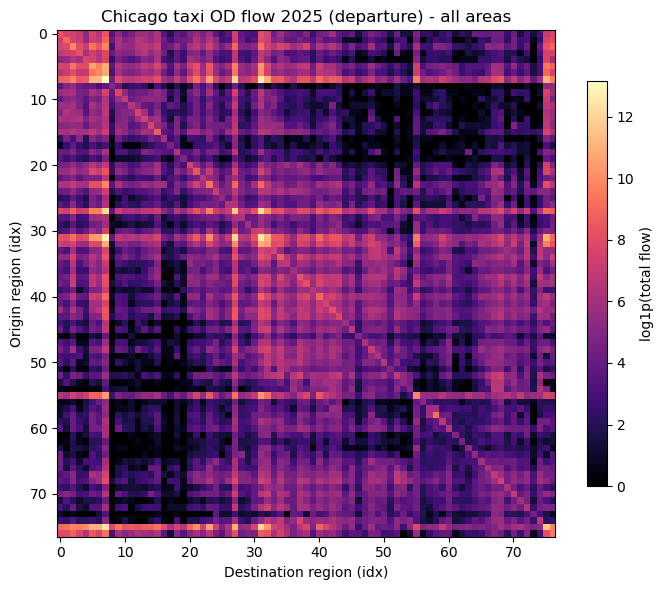

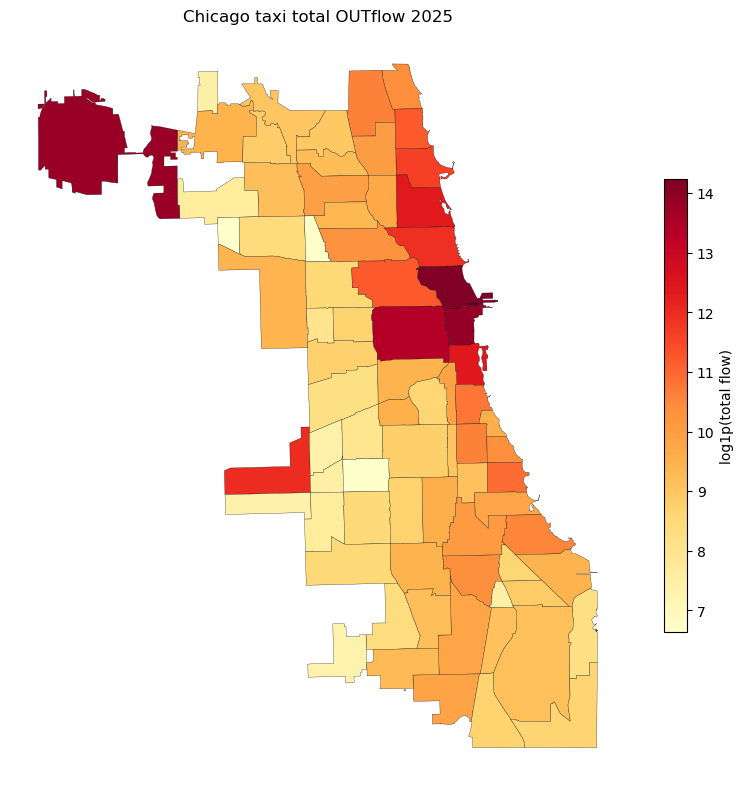

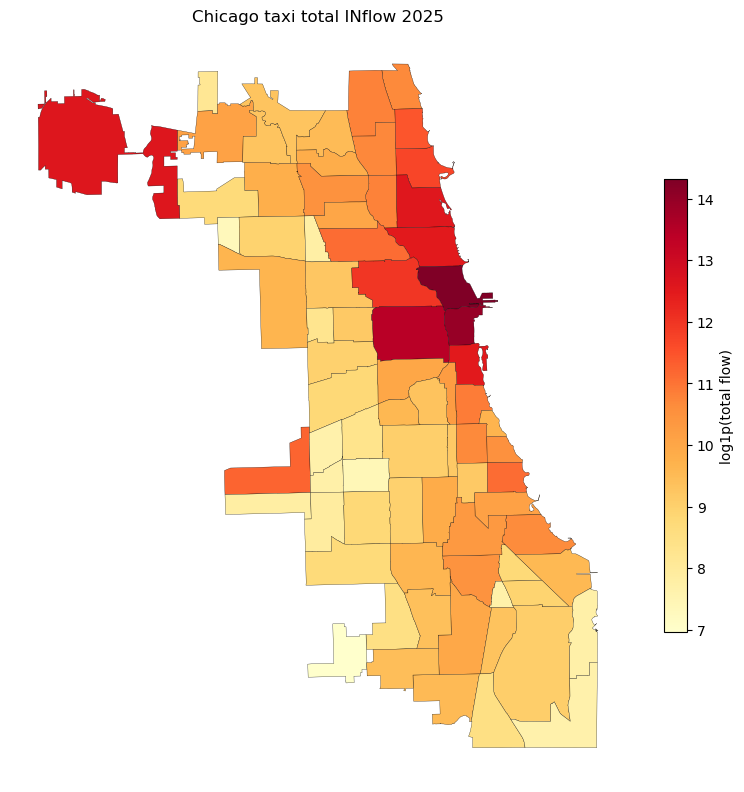

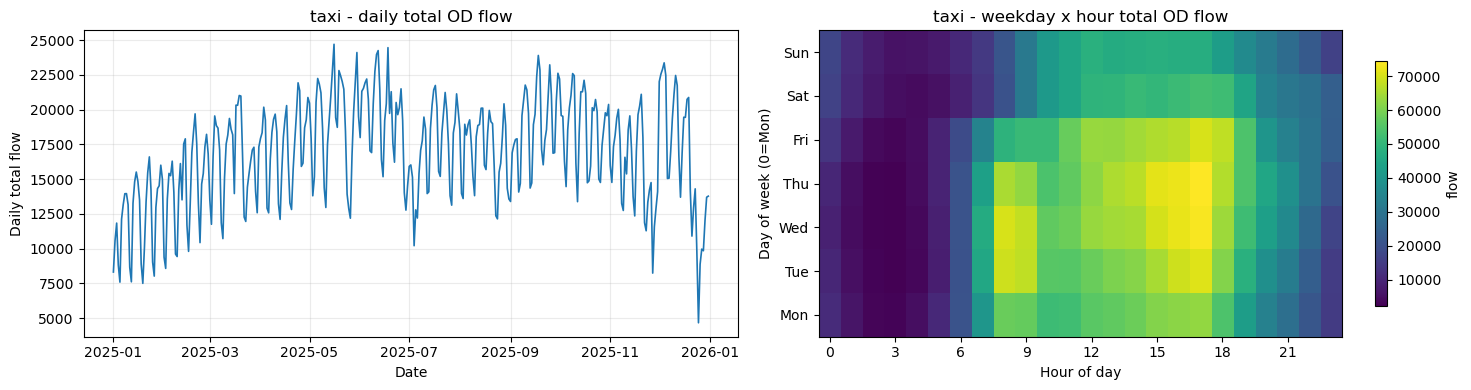

=== Sparsity report: tnp ===
  shape=(77, 77, 35040), total_flow=75,372,215
  nnz cells=25,536,018/207,752,160  zero_rate=87.708%
  dead pairs=5/5929  dead steps=4/35040
  pair totals  min/Q1/med/Q3/max = 0 / 306 / 1,415 / 5,588 / 2,819,527
  pair totals  (non-zero only) Q1/med/Q3 = 306 / 1,418 / 5,602
  step totals  min/Q1/med/Q3/max = 0 / 1,259 / 2,287 / 2,748 / 6,750
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


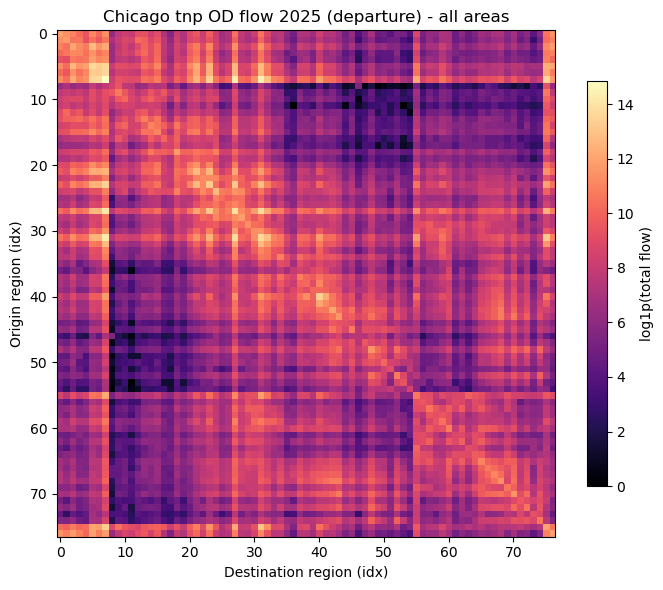

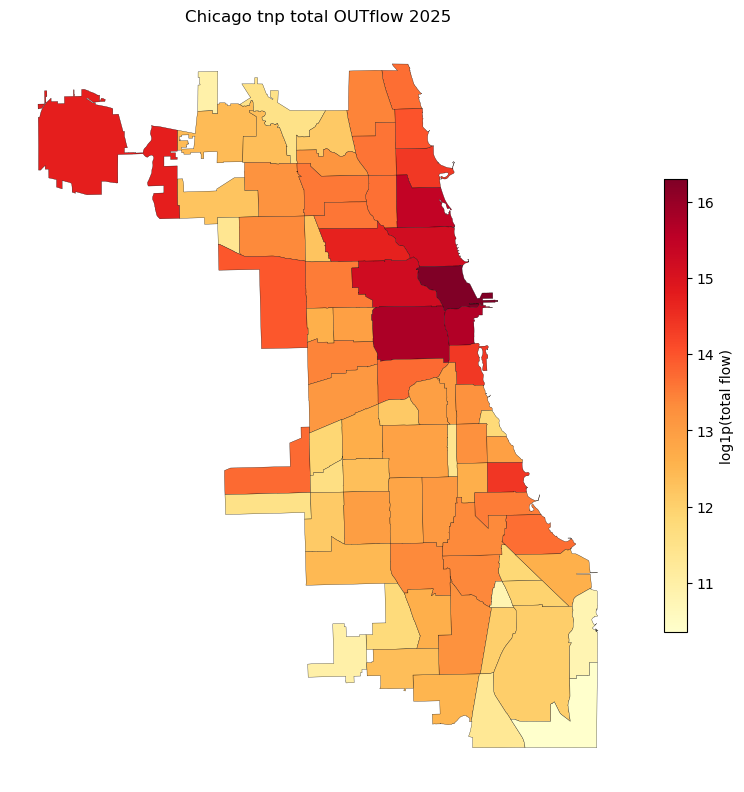

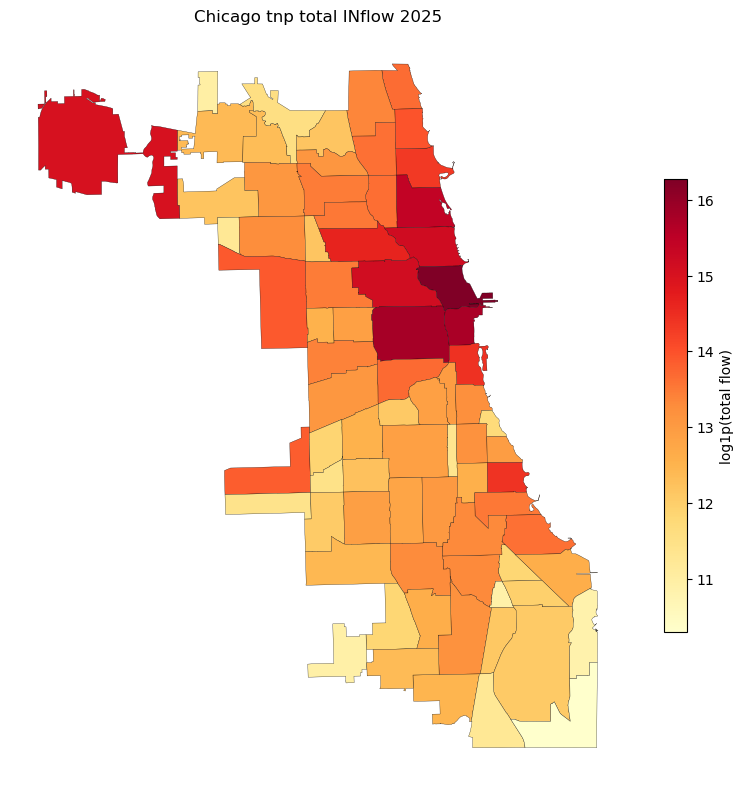

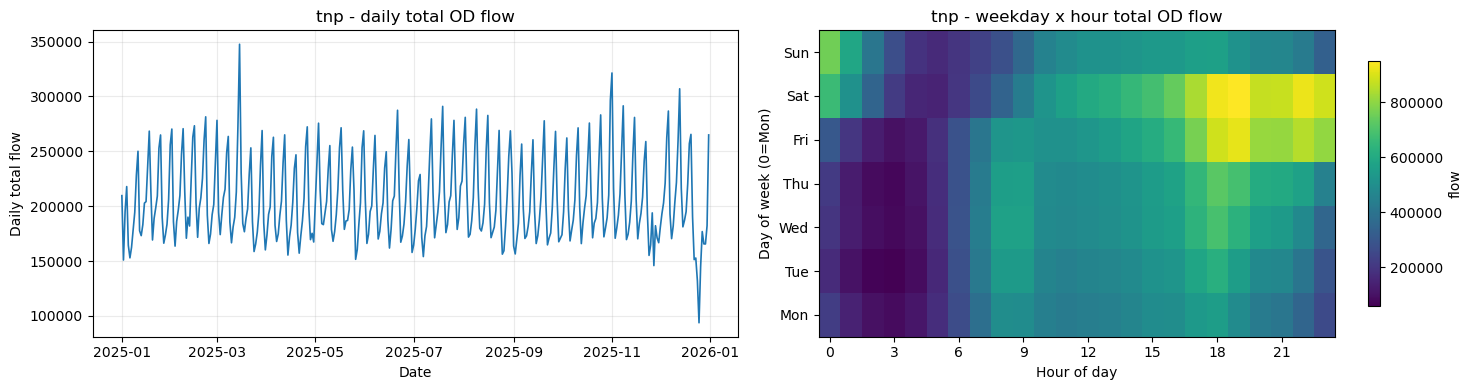

=== Sparsity report: bike ===
  shape=(77, 77, 35040), total_flow=5,403,610
  nnz cells=1,763,280/207,752,160  zero_rate=99.151%
  dead pairs=3016/5929  dead steps=158/35040
  pair totals  min/Q1/med/Q3/max = 0 / 0 / 0 / 11 / 510,975
  pair totals  (non-zero only) Q1/med/Q3 = 2 / 11 / 102
  step totals  min/Q1/med/Q3/max = 0 / 29 / 96 / 234 / 963
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 23:45:00


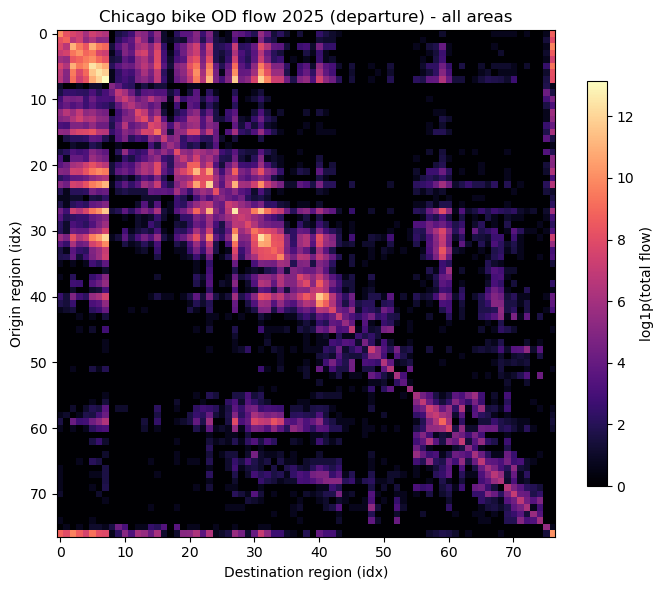

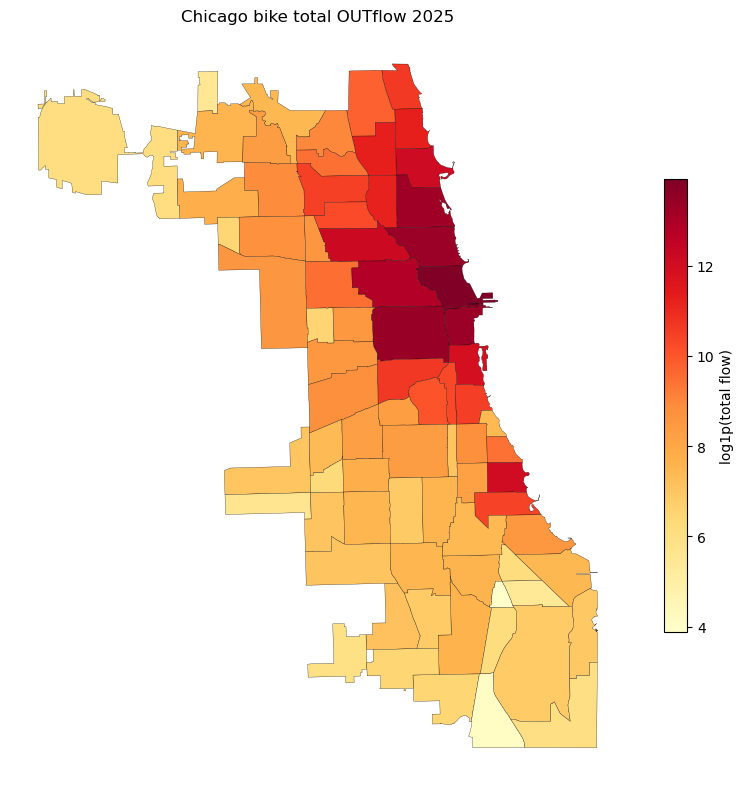

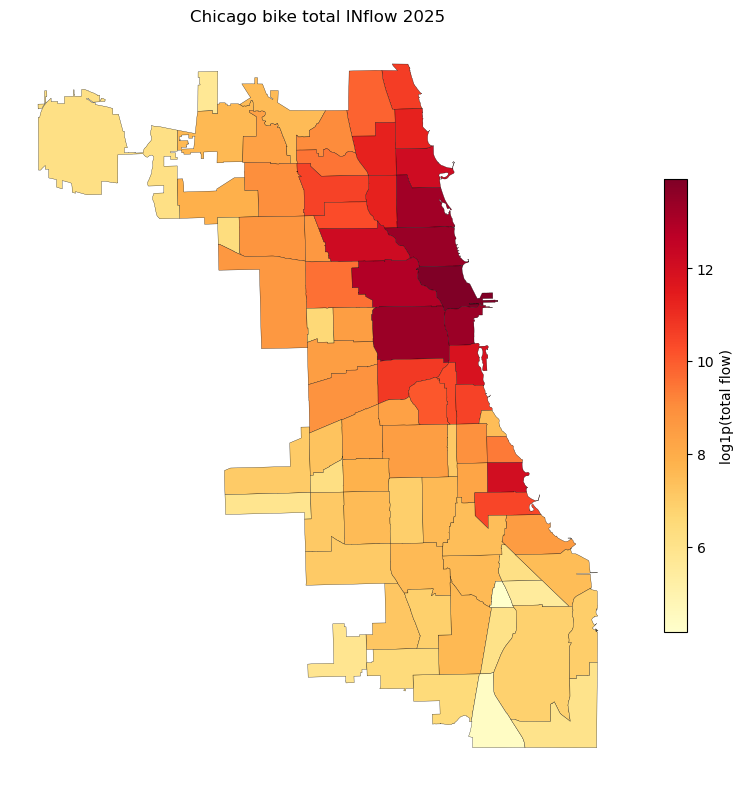

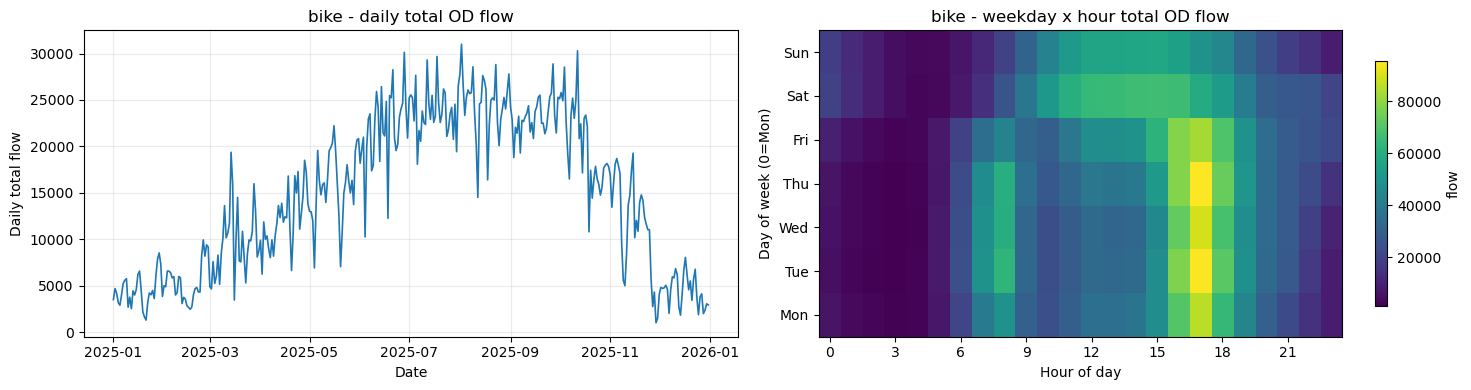

=== Sparsity report: scooter ===
  shape=(77, 77, 8760), total_flow=9,432,242
  nnz cells=1,859,041/51,938,040  zero_rate=96.421%
  dead pairs=2378/5929  dead steps=68/8760
  pair totals  min/Q1/med/Q3/max = 0 / 0 / 2 / 57 / 497,230
  pair totals  (non-zero only) Q1/med/Q3 = 4 / 28 / 275
  step totals  min/Q1/med/Q3/max = 0 / 152 / 651 / 1,775 / 4,829
  first_active=2025-01-01 00:00:00, last_active=2025-12-31 00:00:00


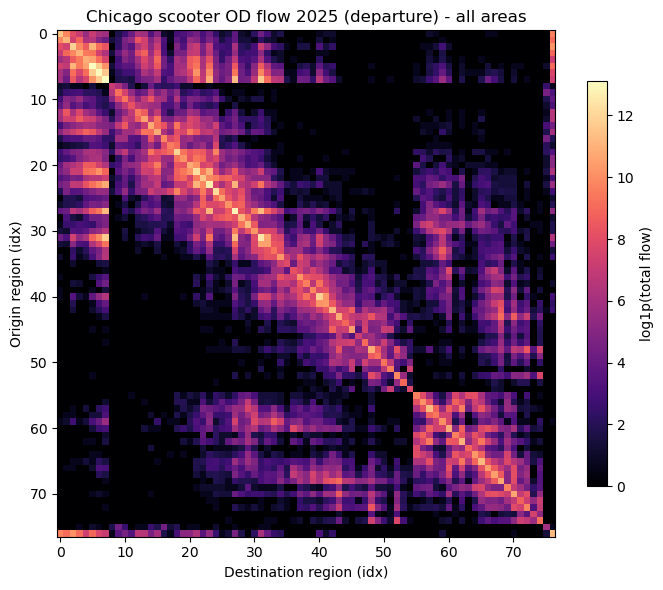

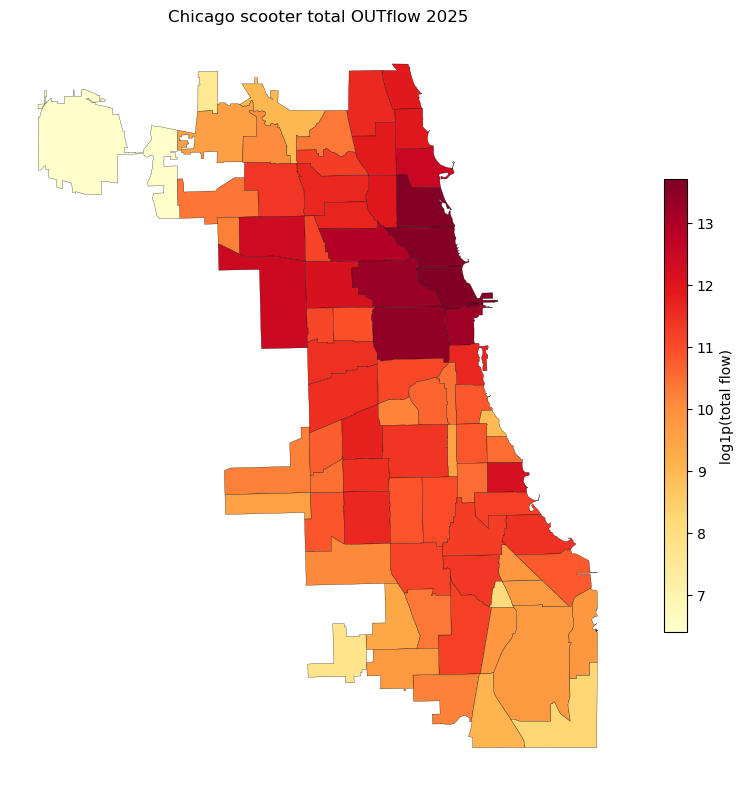

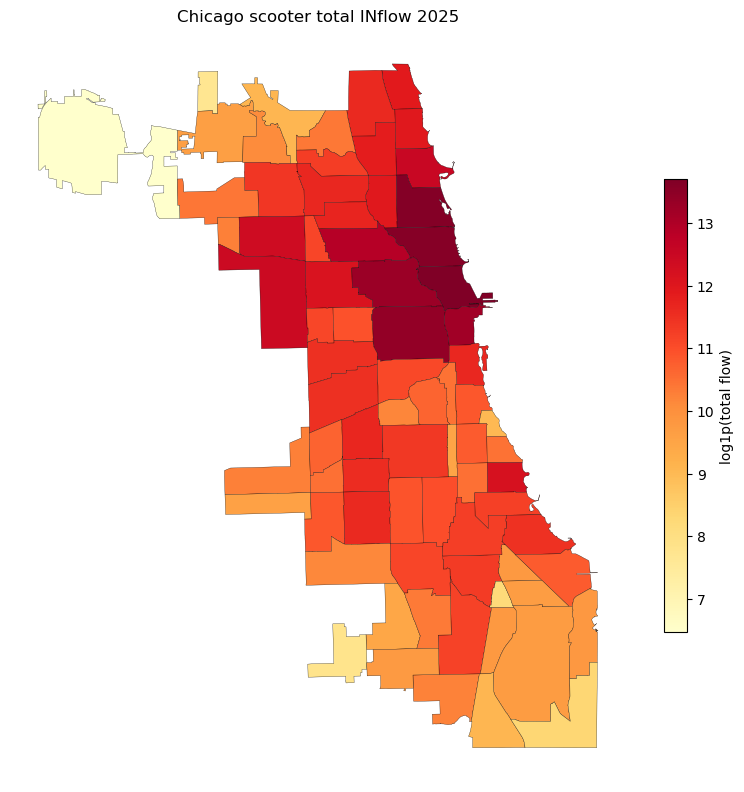

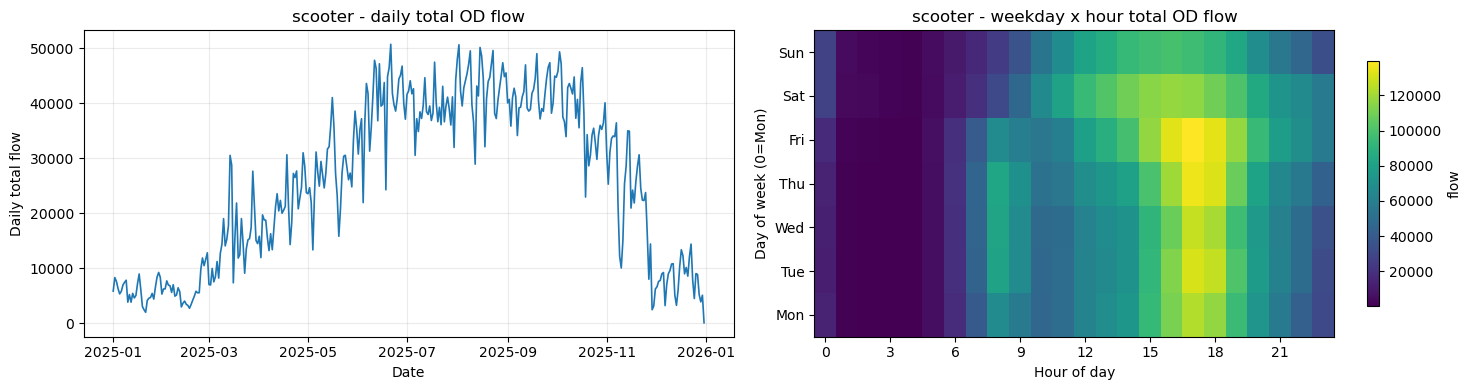

In [15]:
area_active = TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all")
for name, arr, time_index in MOBILITY_VIZ:
    tag = f"{name} [{TARGET_TAG}]" if area_active else name
    viz_arr = arr[np.ix_(sel_idx, sel_idx)] if area_active else arr
    viz_gdf = areas_sel if area_active else areas
    sparsity_report(tag, viz_arr, time_index)
    plot_od_heat(viz_arr, f"Chicago {name} OD flow {YEAR} ({FLOW_MODE}) - {TARGET_TAG if area_active else 'all areas'}")
    plot_area_heat(viz_gdf, viz_arr.sum(axis=(1, 2)), f"Chicago {name} total OUTflow {YEAR}")
    plot_area_heat(viz_gdf, viz_arr.sum(axis=(0, 2)), f"Chicago {name} total INflow {YEAR}")
    plot_temporal_panels(name, viz_arr, time_index)

## Generate dataset (NNDT)

Feed the 15-min `(N, N, M, T)` tensor to `utils/generate.py` with `--fmt NNDT`
(origin, destination, mobility, time). The generator reorders to `(T, N, N, M)`,
fits a per-channel log1p MinMaxScaler over the `M` mobility channels, and writes
`his.npz` + `info.json` + `meta.json` + index files.

In [ ]:
if TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all"):
    src_path = OUT_DIR / f"chi_{area_tag}_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
    DATASET = f"chicago_{area_tag}_od_15min"
else:
    src_path = OUT_DIR / f"chi_{merged_tag}_od_{YEAR}_{FREQ_TAG}.npy"
    DATASET = "chicago_od_15min"

print(f"Source {src_path} shape={tuple(np.load(src_path, mmap_mode='r').shape)} (N, N, M, T)")

for hy in [1, 3, 6, 9, 12]:
    subprocess.run([
        "python3", "/home/dy23a.fsu/st/utils/generate.py",
        "--data_path", str(src_path),
        "--fmt", "NNDT",
        "--clip_neg",
        "--per_channel",
        "--log1p",
        "--dataset", DATASET,
        "--years", f"{YEAR}_12to{hy}",
        "--seq_length_x", "12",
        "--seq_length_y", str(hy),
    ], check=True)

Source /home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_od_2025_15min.npy shape=(77, 77, 3, 35040) (N, N, M, T)
Loaded /home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_od_2025_15min.npy, raw shape: (77, 77, 3, 35040)
Clipped negative values to 0
Reordered NNDT → TNND, shape: (35040, 77, 77, 3)
Raw — max: 547, min: 0, mean: 0.1395, std: 1.7132
Index range: [11, 35039), total=35028, train=28022, val=3503, test=3503
MinMaxScaler(log1p=True) min: [0.0, 0.0, 0.0], max: [4.356709003448486, 6.306275367736816, 5.036952495574951]
Normalized — max: 1.0000, min: 0.0000, mean: 0.0083, std: 0.0431
Saved meta.json to /blue/gtyson.fsu/dy23a.fsu/datasets/chicago_od_15min/2025/meta.json
Saved to /blue/gtyson.fsu/dy23a.fsu/datasets/chicago_od_15min/2025
Saved info.json to /blue/gtyson.fsu/dy23a.fsu/datasets/chicago_od_15min/2025/info.json


CompletedProcess(args=['python3', '/home/dy23a.fsu/st/utils/generate.py', '--data_path', '/home/dy23a.fsu/st/datasets/raw/Chicago/chi_taxi_tnp_bike_od_2025_15min.npy', '--fmt', 'NNDT', '--clip_neg', '--per_channel', '--log1p', '--dataset', 'chicago_od_15min', '--years', '2025', '--seq_length_x', '12', '--seq_length_y', '1'], returncode=0)

## Adjacency

Distance-based adjacency over the selected community-area centroids, saved
alongside the OD dataset (mirrors the flow notebook). Centroids are computed in
a projected CRS (EPSG:3435, Illinois State Plane East) to avoid the geographic
-CRS centroid warning.

In [17]:
sys.path.insert(0, "/home/dy23a.fsu/st/utils")
from get_adj_mat import get_adjacency_matrix

ADJ_DIR = Path("/home/dy23a.fsu/st/datasets") / DATASET
ADJ_DIR.mkdir(parents=True, exist_ok=True)
if TARGET_AREAS is not None and (not isinstance(TARGET_AREAS, str) or TARGET_AREAS.lower() != "all"):
    ADJ_OUT = ADJ_DIR / f"{TARGET_TAG}.npy"
    adj_gdf = areas_sel
else:
    ADJ_OUT = ADJ_DIR / "chicago.npy"
    adj_gdf = areas

ctr = adj_gdf.set_geometry("geometry").to_crs("EPSG:3435").centroid.reset_index(drop=True)
N_adj = len(ctr)
ids = list(range(N_adj))
distance = [[i, j, ctr[i].distance(ctr[j])] for i in ids for j in ids]
adj_mx = get_adjacency_matrix(distance_df=distance, sensor_ids=ids)
np.save(ADJ_OUT, adj_mx)
print(f"Saved {ADJ_OUT} shape={adj_mx.shape}")

Saved /home/dy23a.fsu/st/datasets/chicago_od_15min/chicago.npy shape=(77, 77)
